In [28]:
import numpy as np
import pandas as pd
import os
import random
from PIL import Image
from tqdm import tqdm
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

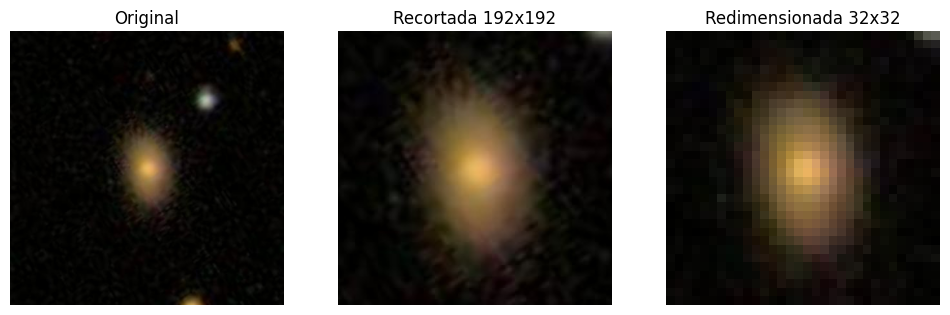

In [29]:
# Visualización de una imagen antes y después de recortar y redimensionar
import matplotlib.pyplot as plt

# Selecciona un nombre de archivo válido
nombre_ejemplo = os.listdir("images_training_rev1")[56803]
ruta = os.path.join("images_training_rev1", nombre_ejemplo)

# Imagen original
img_original = Image.open(ruta)

# Recorte y resize manual para mostrar el proceso
def recortar_y_redimensionar(img, crop_size=(192, 192), resize_to=(32,32)):
    w, h = img.size
    cw, ch = crop_size
    left = (w - cw) // 2
    top = (h - ch) // 2
    img_cropped = img.crop((left, top, left + cw, top + ch))
    img_resized = img_cropped.resize(resize_to)
    return img_cropped, img_resized

img_cropped, img_resized = recortar_y_redimensionar(img_original)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img_original)
plt.title('Original')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(img_cropped)
plt.title('Recortada 192x192')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(img_resized)
plt.title('Redimensionada 32x32')
plt.axis('off')
plt.show()

In [30]:
def cargar_mismas_imagenes(
    carpeta="images_training_rev1",
    archivo_clasificaciones="training_solutions_rev1.csv",
    max_imagenes=2000,
    crop_size=(192, 192),
    resize_to=(32, 32)
    ):
    """Carga las mismas imágenes en RGB y en escala de grises, recorta y redimensiona, usando tqdm para mostrar progreso."""
    df = pd.read_csv(archivo_clasificaciones)
    if "GalaxyID" not in df.columns:
        raise ValueError("El archivo CSV debe tener una columna 'GalaxyID'.")
    galaxy_ids = df["GalaxyID"].astype(str).tolist()
    archivos = [f for f in os.listdir(carpeta) if f.lower().endswith((".jpg", ".png", ".jpeg"))]
    archivos_validos = [f for f in archivos if f.split(".")[0] in galaxy_ids]
    if len(archivos_validos) > max_imagenes:
        archivos_validos = random.sample(archivos_validos, max_imagenes)
    print(f"Se seleccionaron {len(archivos_validos)} imágenes para ambos conjuntos.")

    # Cargar en gris
    X_gray, y_gray = [], []
    for nombre in tqdm(archivos_validos, desc="Cargando imágenes en gris"):
        galaxy_id = nombre.split(".")[0]
        fila = df[df["GalaxyID"] == int(galaxy_id)].iloc[0]
        etiqueta = fila.drop("GalaxyID").idxmax()
        ruta = os.path.join(carpeta, nombre)
        try:
            img = Image.open(ruta).convert("L")
            w, h = img.size
            cw, ch = crop_size
            left = (w - cw) // 2
            top = (h - ch) // 2
            img_cropped = img.crop((left, top, left + cw, top + ch))
            img_resized = img_cropped.resize(resize_to)
            X_gray.append(np.array(img_resized))
            y_gray.append(etiqueta)
        except Exception as e:
            print(f"Error al cargar {nombre} (gris): {e}")

    # Cargar en RGB
    X_rgb, y_rgb = [], []
    for nombre in tqdm(archivos_validos, desc="Cargando imágenes en RGB"):
        galaxy_id = nombre.split(".")[0]
        fila = df[df["GalaxyID"] == int(galaxy_id)].iloc[0]
        etiqueta = fila.drop("GalaxyID").idxmax()
        ruta = os.path.join(carpeta, nombre)
        try:
            img = Image.open(ruta).convert("RGB")
            w, h = img.size
            cw, ch = crop_size
            left = (w - cw) // 2
            top = (h - ch) // 2
            img_cropped = img.crop((left, top, left + cw, top + ch))
            img_resized = img_cropped.resize(resize_to)
            X_rgb.append(np.array(img_resized))
            y_rgb.append(etiqueta)
        except Exception as e:
            print(f"Error al cargar {nombre} (RGB): {e}")

    X_gray = np.array(X_gray)
    X_rgb = np.array(X_rgb)
    print(f"Se cargaron {len(X_gray)} imágenes en gris y {len(X_rgb)} en RGB.")
    return X_gray, y_gray, X_rgb, y_rgb

# Uso:
X_gray, y_gray, X_rgb, y_rgb = cargar_mismas_imagenes(
    carpeta="images_training_rev1",
    max_imagenes=2000,
    archivo_clasificaciones="training_solutions_rev1.csv",
    crop_size=(192, 192),
    resize_to=(32, 32)
    )

Se seleccionaron 2000 imágenes para ambos conjuntos.


Cargando imágenes en RGB: 100%|██████████| 2000/2000 [00:10<00:00, 187.98it/s]

Se cargaron 2000 imágenes en gris y 2000 en RGB.


In [31]:
# --- Preprocesamiento y splits para ambos conjuntos ---

# Aplanar imágenes (cada imagen se convierte en un vector)
X_r_rgb = np.array([img.flatten() for img in tqdm(X_rgb, desc='Aplanando RGB')])
X_r_gray = np.array([img.flatten() for img in tqdm(X_gray, desc='Aplanando Gray')])
print(f"Forma RGB aplanada: {X_r_rgb.shape} | Forma Gray aplanada: {X_r_gray.shape}")

# Codificar etiquetas (usamos las mismas para ambos conjuntos)
le = LabelEncoder()
y_enc = le.fit_transform(y_rgb)
print("Ejemplo etiquetas codificadas:", y_rgb[:5], "->", y_enc[:5])

# División en train/test para ambos conjuntos
from sklearn.model_selection import train_test_split
X_rgb_train, X_rgb_test, y_train, y_test = train_test_split(X_r_rgb, y_enc, test_size=0.3, random_state=40)
X_gray_train, X_gray_test, _, _ = train_test_split(X_r_gray, y_enc, test_size=0.3, random_state=40)
print("Tamaño Train/Test RGB:", X_rgb_train.shape, X_rgb_test.shape)
print("Tamaño Train/Test Gray:", X_gray_train.shape, X_gray_test.shape)
print("Tamaño Etiquetas Train:", y_train.shape, "| Test:", y_test.shape)

Aplanando Gray: 100%|██████████| 2000/2000 [00:00<00:00, 172996.66it/s]

Forma RGB aplanada: (2000, 3072) | Forma Gray aplanada: (2000, 1024)
Ejemplo etiquetas codificadas: ['Class6.2', 'Class1.2', 'Class6.2', 'Class6.2', 'Class6.1'] -> [3 1 3 3 2]
Tamaño Train/Test RGB: (1400, 3072) (600, 3072)
Tamaño Train/Test Gray: (1400, 1024) (600, 1024)
Tamaño Etiquetas Train: (1400,) | Test: (600,)


In [32]:
# --- Definición de pipelines para ambos conjuntos ---
# Puedes cambiar los hiperparámetros si lo deseas
# Pipelines para RGB
logreg_pipeline_rgb = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=1000, random_state=40)),
    ('logreg', LogisticRegression(C=0.0003, max_iter=10000, solver='lbfgs', random_state=40, class_weight='balanced'))
])

tree_pipeline_rgb = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=1000, random_state=40)),
    ('tree', DecisionTreeClassifier(criterion='entropy', max_depth=20, min_samples_leaf=20, random_state=40))
])

svm_pipeline_rgb = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=1000, random_state=40)),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', random_state=40))
])

# Pipelines para GRAYSCALE
logreg_pipeline_gray = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=1000, random_state=40)),
    ('logreg', LogisticRegression(C=0.0003, max_iter=10000, solver='lbfgs', random_state=40, class_weight='balanced'))
])

tree_pipeline_gray = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=1000, random_state=40)),
    ('tree', DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=5, random_state=40))
])

svm_pipeline_gray = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=1000, random_state=40)),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', random_state=40))
])

In [33]:
# --- Entrenamiento y evaluación para ambos conjuntos ---
print("\n--- PIPELINES RGB ---")
for name, pipe in zip(["LogReg", "Árbol", "SVM"], [logreg_pipeline_rgb, tree_pipeline_rgb, svm_pipeline_rgb]):
    print(f"\nModelo {name} (RGB):")
    pipe.fit(X_rgb_train, y_train)
    y_pred = pipe.predict(X_rgb_test)
    print(classification_report(y_test, y_pred, zero_division=1))



--- PIPELINES RGB ---

Modelo LogReg (RGB):


              precision    recall  f1-score   support

           0       0.20      0.35      0.26        54
           1       0.48      0.66      0.56       149
           2       0.25      0.35      0.29        40
           3       0.74      0.51      0.60       357

    accuracy                           0.52       600
   macro avg       0.42      0.47      0.43       600
weighted avg       0.59      0.52      0.54       600


Modelo Árbol (RGB):
              precision    recall  f1-score   support

           0       0.15      0.06      0.08        54
           1       0.38      0.40      0.39       149
           2       0.11      0.03      0.04        40
           3       0.63      0.73      0.67       357

    accuracy                           0.54       600
   macro avg       0.32      0.30      0.30       600
weighted avg       0.49      0.54      0.51       600


Modelo SVM (RGB):
              precision    recall  f1-score   support

           0       0.15      0.06  

In [34]:
# --- ENTRENAMIENTO DE PIPELINES GRAYSCALE ---
# Este bloque asegura que los modelos Grayscale se ajusten con los datos X_gray_train
# antes de intentar usarlos en la celda de las Matrices de Confusión.

from sklearn.metrics import classification_report

print("\n--- PIPELINES GRAYSCALE ---")
for name, pipe in zip(["LogReg", "Árbol", "SVM"], [logreg_pipeline_gray, tree_pipeline_gray, svm_pipeline_gray]):
    print(f"\nModelo {name} (Gray):")
    
    # 🚨 LÍNEA CRÍTICA: Ajustar (entrenar) la pipeline con los datos de Grayscale
    pipe.fit(X_gray_train, y_train) 
    
    # Evaluación inmediata (opcional, pero útil para verificar)
    y_pred = pipe.predict(X_gray_test)
    print(classification_report(y_test, y_pred, zero_division=1))


--- PIPELINES GRAYSCALE ---

Modelo LogReg (Gray):
              precision    recall  f1-score   support

           0       0.14      0.24      0.18        54
           1       0.43      0.71      0.54       149
           2       0.23      0.40      0.29        40
           3       0.76      0.41      0.53       357

    accuracy                           0.47       600
   macro avg       0.39      0.44      0.38       600
weighted avg       0.59      0.47      0.48       600


Modelo Árbol (Gray):
              precision    recall  f1-score   support

           0       0.14      0.24      0.18        54
           1       0.43      0.71      0.54       149
           2       0.23      0.40      0.29        40
           3       0.76      0.41      0.53       357

    accuracy                           0.47       600
   macro avg       0.39      0.44      0.38       600
weighted avg       0.59      0.47      0.48       600


Modelo Árbol (Gray):
              precision    recall 

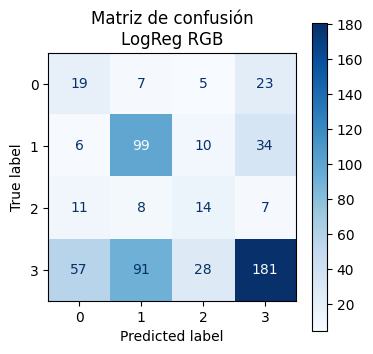

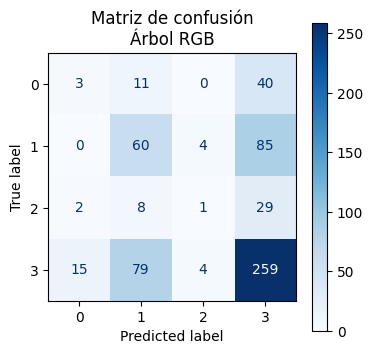

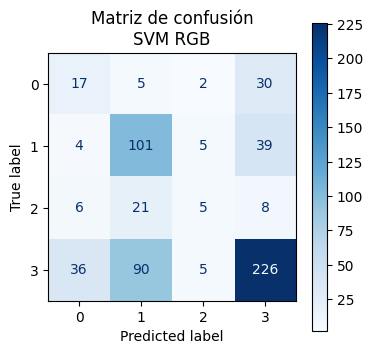

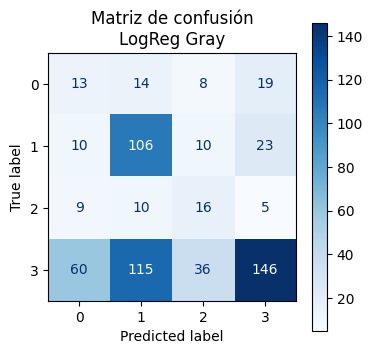

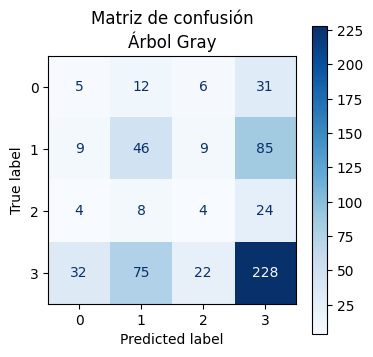

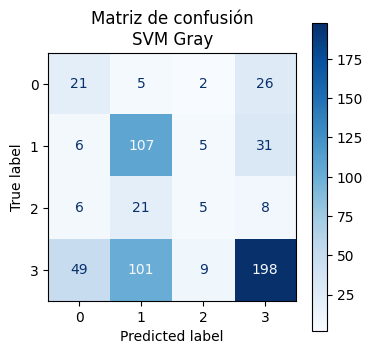

In [35]:
# --- Matrices de confusión para cada modelo y conjunto ---
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

modelos = [
    ("LogReg RGB", logreg_pipeline_rgb, X_rgb_test),
    ("Árbol RGB", tree_pipeline_rgb, X_rgb_test),
    ("SVM RGB", svm_pipeline_rgb, X_rgb_test),
    ("LogReg Gray", logreg_pipeline_gray, X_gray_test),
    ("Árbol Gray", tree_pipeline_gray, X_gray_test),
    ("SVM Gray", svm_pipeline_gray, X_gray_test),
]

for nombre, modelo, X_test_ in modelos:
    y_pred = modelo.predict(X_test_)
    fig, ax = plt.subplots(1, 1, figsize=(4,4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues')
    ax.set_title(f"Matriz de confusión\n{nombre}")
    plt.show()

In [36]:
# --- Comparación porcentual de métricas entre modelos y RGB vs Gray ---
from sklearn.metrics import classification_report
import pandas as pd

# Definir modelos y conjuntos
modelos_rgb = [
    ("LogReg RGB", logreg_pipeline_rgb, X_rgb_test),
    ("Árbol RGB", tree_pipeline_rgb, X_rgb_test),
    ("SVM RGB", svm_pipeline_rgb, X_rgb_test),
]
modelos_gray = [
    ("LogReg Gray", logreg_pipeline_gray, X_gray_test),
    ("Árbol Gray", tree_pipeline_gray, X_gray_test),
    ("SVM Gray", svm_pipeline_gray, X_gray_test),
]

# Calcular métricas para cada modelo
metricas = {}
for nombre, modelo, X_test_ in modelos_rgb + modelos_gray:
    y_pred = modelo.predict(X_test_)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=1)
    # Usar solo las métricas globales (accuracy, macro avg, weighted avg)
    metricas[nombre] = {
        "accuracy": report["accuracy"],
        "precision": report["macro avg"]["precision"],
        "recall": report["macro avg"]["recall"],
        "f1-score": report["macro avg"]["f1-score"],
        "precision_weighted": report["weighted avg"]["precision"],
        "recall_weighted": report["weighted avg"]["recall"],
        "f1-score_weighted": report["weighted avg"]["f1-score"],
    }

# Convertir a DataFrame
df_metricas = pd.DataFrame(metricas).T

# Comparar diferencia porcentual entre modelos y entre RGB vs Gray
# Ejemplo: diferencia porcentual entre LogReg RGB y LogReg Gray
comparaciones = []
for metrica in df_metricas.columns:
    for m1, m2 in [("LogReg RGB", "LogReg Gray"), ("Árbol RGB", "Árbol Gray"), ("SVM RGB", "SVM Gray")]:
        val1 = df_metricas.loc[m1, metrica]
        val2 = df_metricas.loc[m2, metrica]
        diff = 100 * (val1 - val2) / (val2 if val2 != 0 else 1)
        comparaciones.append({
            "Modelo RGB": m1,
            "Modelo Gray": m2,
            "Métrica": metrica,
            "% Diferencia": diff
        })

df_comparacion = pd.DataFrame(comparaciones)

print("Métricas globales por modelo:")
print(df_metricas.round(3))
print("\nComparación porcentual entre RGB y Gray:")
print(df_comparacion.round(2))


Métricas globales por modelo:
             accuracy  precision  recall  f1-score  precision_weighted  \
LogReg RGB      0.522      0.418   0.468     0.427               0.594   
Árbol RGB       0.538      0.317   0.302     0.296               0.488   
SVM RGB         0.582      0.444   0.438     0.426               0.603   
LogReg Gray     0.468      0.390   0.440     0.384               0.586   
Árbol Gray      0.472      0.286   0.285     0.285               0.465   
SVM Gray        0.552      0.426   0.447     0.418               0.600   

             recall_weighted  f1-score_weighted  
LogReg RGB             0.522              0.539  
Árbol RGB              0.538              0.507  
SVM RGB                0.582              0.582  
LogReg Gray            0.468              0.485  
Árbol Gray             0.472              0.468  
SVM Gray               0.552              0.558  

Comparación porcentual entre RGB y Gray:
    Modelo RGB  Modelo Gray             Métrica  % Diferenc

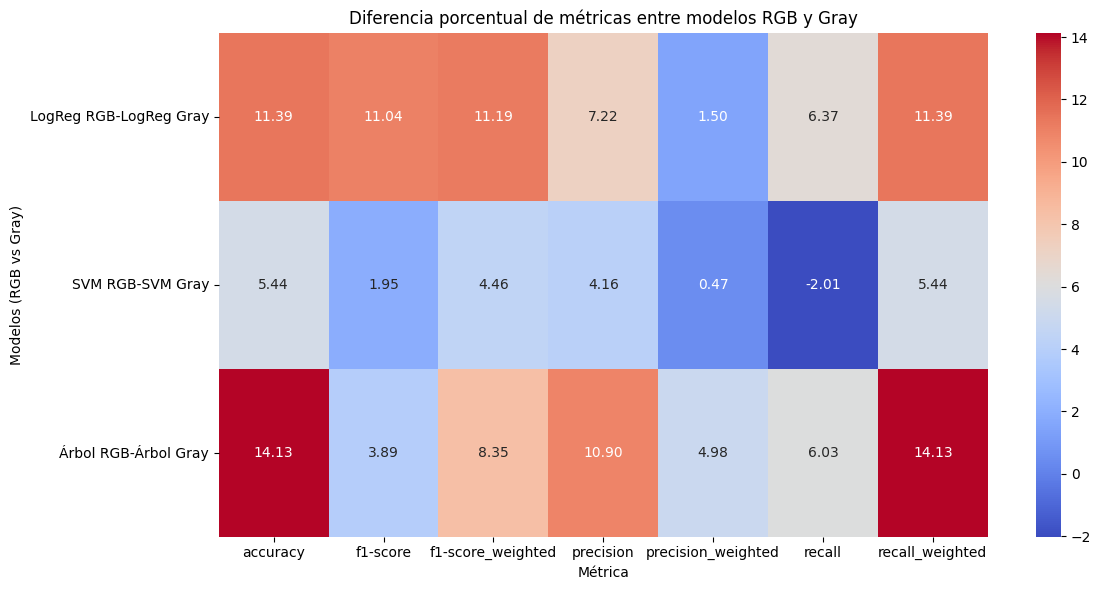

In [37]:
# --- Visualización gráfica de la comparación porcentual de métricas ---
import matplotlib.pyplot as plt
import seaborn as sns

# Pivot para gráfico: Métrica vs Modelo (RGB vs Gray)
df_pivot = df_comparacion.pivot(index=["Modelo RGB", "Modelo Gray"], columns="Métrica", values="% Diferencia")

plt.figure(figsize=(12,6))
sns.heatmap(df_pivot, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Diferencia porcentual de métricas entre modelos RGB y Gray")
plt.ylabel("Modelos (RGB vs Gray)")
plt.xlabel("Métrica")
plt.tight_layout()
plt.show()


Clases en el LabelEncoder: ['Class1.1' 'Class1.2' 'Class6.1' 'Class6.2']


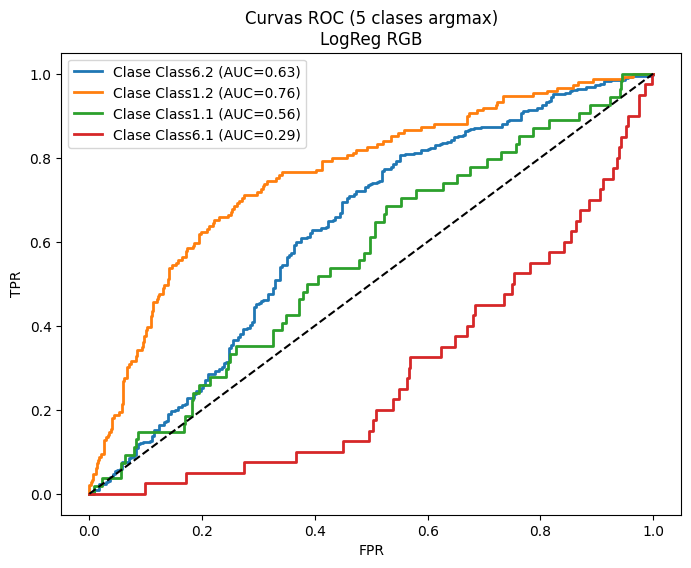

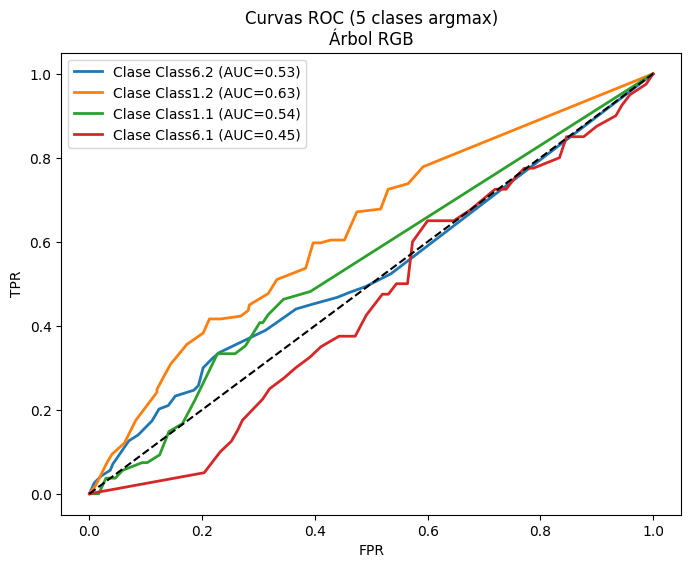

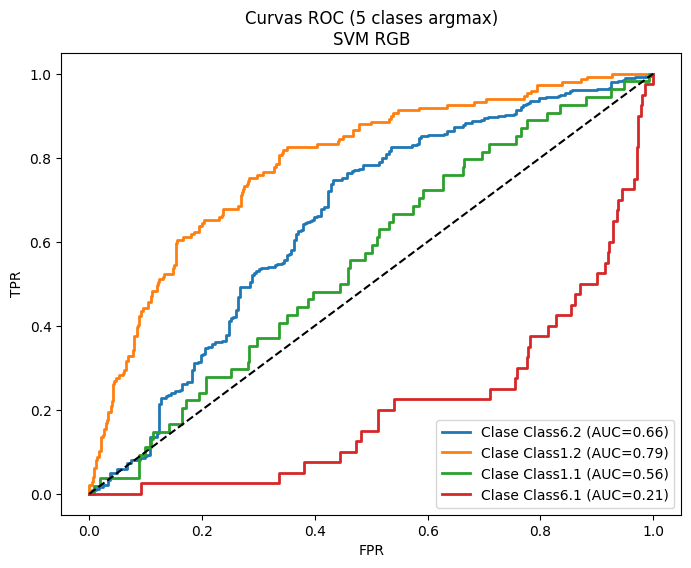

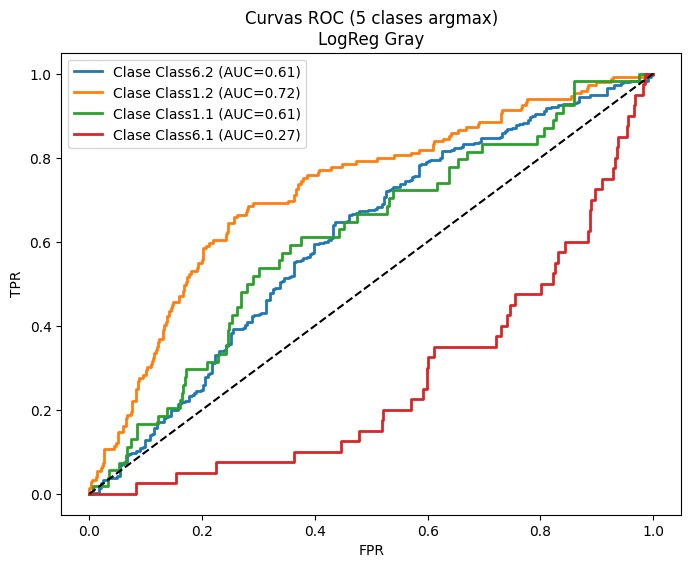

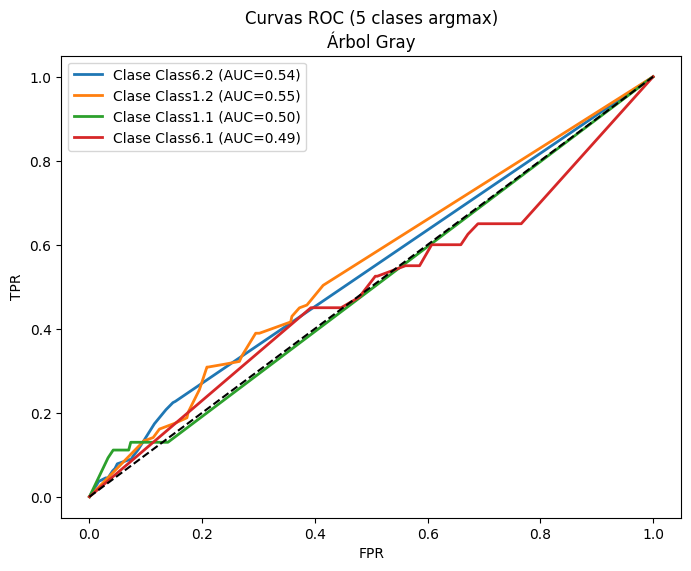

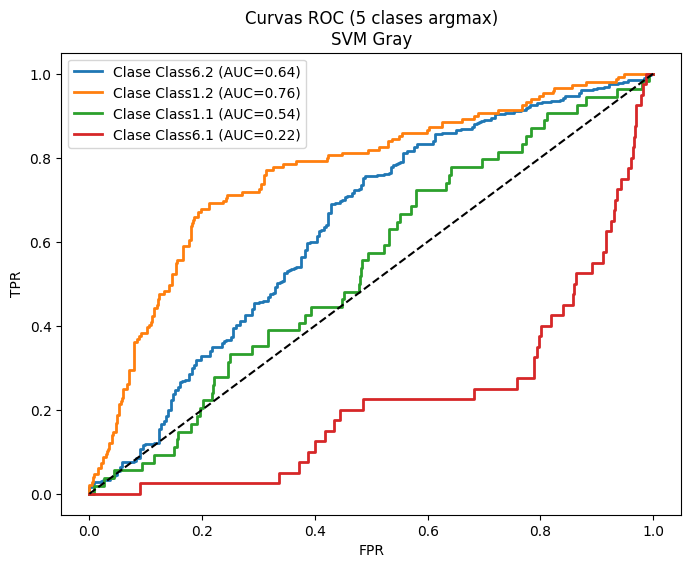

In [38]:
# --- Curvas ROC para las 5 clases argmax ---
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Definir las 5 clases argmax (ajusta los nombres si es necesario)
clases_argmax = ["Class6.2", "Class1.2", "Class1.1", "Class6.1", "Class1.3"]

# Ver las clases presentes en el encoder
print("Clases en el LabelEncoder:", le.classes_)

# Solo usar las clases que realmente están en el encoder
clases_argmax_validas = [c for c in clases_argmax if c in le.classes_]
clases_argmax_idx = [le.transform([c])[0] for c in clases_argmax_validas]

# Filtrar conjunto de test para solo esas clases
mask_argmax = np.isin(y_test, clases_argmax_idx)
y_test_argmax = y_test[mask_argmax]

for nombre, modelo, X_test_ in modelos:
    X_test_argmax = X_test_[mask_argmax]
    # Binarizar etiquetas para ROC
    y_test_bin = label_binarize(y_test_argmax, classes=clases_argmax_idx)
    # Obtener scores
    if hasattr(modelo, "predict_proba"):
        y_score = modelo.predict_proba(X_test_argmax)
    else:
        y_score = modelo.decision_function(X_test_argmax)
    # Curvas ROC multiclase
    plt.figure(figsize=(8,6))
    for i, clase in enumerate(clases_argmax_validas):
        fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_score[:,i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'Clase {clase} (AUC={roc_auc:.2f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title(f'Curvas ROC (5 clases argmax)\n{nombre}')
    plt.legend()
    plt.show()


In [39]:

print("\n--- PIPELINES GRAYSCALE ---")
for name, pipe in zip(["LogReg", "Árbol", "SVM"], [logreg_pipeline_gray, tree_pipeline_gray, svm_pipeline_gray]):
    print(f"\nModelo {name} (Gray):")
    pipe.fit(X_gray_train, y_train)
    y_pred = pipe.predict(X_gray_test)
    print(classification_report(y_test, y_pred, zero_division=1))


--- PIPELINES GRAYSCALE ---

Modelo LogReg (Gray):
              precision    recall  f1-score   support

           0       0.14      0.24      0.18        54
           1       0.43      0.71      0.54       149
           2       0.23      0.40      0.29        40
           3       0.76      0.41      0.53       357

    accuracy                           0.47       600
   macro avg       0.39      0.44      0.38       600
weighted avg       0.59      0.47      0.48       600


Modelo Árbol (Gray):
              precision    recall  f1-score   support

           0       0.14      0.24      0.18        54
           1       0.43      0.71      0.54       149
           2       0.23      0.40      0.29        40
           3       0.76      0.41      0.53       357

    accuracy                           0.47       600
   macro avg       0.39      0.44      0.38       600
weighted avg       0.59      0.47      0.48       600


Modelo Árbol (Gray):
              precision    recall 